In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
import os

In [90]:
df = pd.read_csv("Medical_insurance.csv")

In [91]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 151.7 KB


In [93]:
is_smoker = df['smoker'].value_counts().idxmax()

In [94]:
print(df['sex'].unique())
print(df['smoker'].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [95]:
df['sex'] = df['sex'].str.strip().str.lower().map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].str.strip().str.lower().map({'no': 0, 'yes': 1})


In [96]:
df['region'] = df['region'].map({'northwest': 1,'northeast': 2,'southwest': 3,'southeast': 4})

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   int64  
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


In [65]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,NaN,27.900,0,NaN,3,16884.92400
1,18,NaN,33.770,1,NaN,4,1725.55230
2,28,NaN,33.000,3,NaN,4,4449.46200
3,33,NaN,22.705,0,NaN,1,21984.47061
4,32,NaN,28.880,0,NaN,1,3866.85520


In [66]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


<Axes: xlabel='bmi', ylabel='charges'>

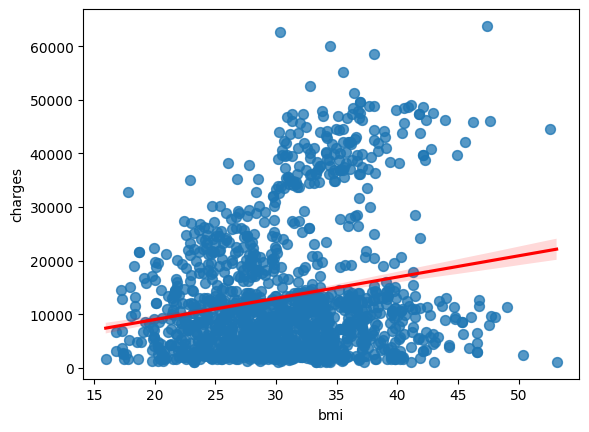

In [98]:
sns.regplot(x='bmi', y='charges', data=df, line_kws={'color': 'red'}, scatter_kws={'s':50, 'alpha':0.5})

<Axes: >

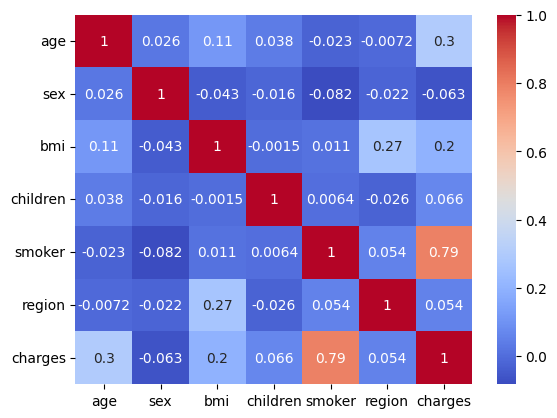

In [106]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [110]:
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.6221791718835359


In [111]:
Z = df[["age", "sex", "bmi", "children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))

0.7504083816310174


In [115]:
Input=[('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z, Y)
ypipe=pipe.predict(Z)
print(r2_score(Y, ypipe))

0.8452576157336337


In [116]:
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

In [117]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test, yhat))

0.6760807753399254


In [118]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test, y_hat))

0.7835895574158702
